# Article — Solving PDEs, then Learning the *Operator*
## From a PINN that solves one equation to a **Fourier Neural Operator (FNO)** that never needs retraining — on CPU with **NVIDIA Modulus**

**Series:** Physics-Informed Neural Networks — from Differential Equations to Engineering Intelligence

---

### The story this notebook tells

A PINN is a fantastic **single-instance solver**: give it one PDE with one set of initial/boundary conditions
and it learns *that* solution. But change the initial condition and you must **retrain from scratch**. For a
digital twin — where conditions change constantly — that's a dealbreaker.

The fix is to stop learning a *function* and start learning an **operator**: a map from an entire input function
(the initial/boundary condition, or a coefficient field) to the entire solution function. Train it once on a
family of problems and it solves *new* ones in a single forward pass, with **no retraining**. This is exactly the
idea powering NVIDIA's use of neural operators for digital twins and simulation acceleration.

> *"FNO learns the full operator mapping: after the initial training, you can evaluate new initial and boundary
> conditions without retraining."*

We'll demonstrate that claim end-to-end. The plan:

| Part | What we do | Key idea |
|---|---|---|
| §2–§4 | **PINN** for the 1-D heat equation (forward) | mesh-free single-instance solve |
| §5 | Compare PINN settings for a PDE | spectral bias is worse in 2-D |
| §6 | **Inverse PDE**: recover the diffusivity $\nu$ from data | parameter estimation |
| §7 | The wall: change the IC → the PINN must **retrain** | motivation for operators |
| §8–§10 | **FNO** learns the solution operator | one training, infinite ICs |
| §11 | Speed & **resolution invariance**; advanced operators | why this scales to digital twins |

Everything runs on **CPU**. We use the same CPU-friendly NVIDIA Modulus stack as notebook 1, now including
`modulus.models.fno.FNO` and `modulus.models.afno`.

---
## §0 — Setup (same CPU-friendly Modulus install as notebook 1)

Idempotent: installs the Modulus core with `--no-deps` plus only its CPU-safe dependencies, and does nothing if
Modulus already imports. (See notebook 1 §0 for *why* the plain install fails on CPU.)

In [1]:
# ── Idempotent CPU install of the NVIDIA Modulus stack ───────────────────────
import importlib, subprocess, sys
def _pip(*a): subprocess.run([sys.executable,"-m","pip","install","--break-system-packages",*a], check=True)
try:
    import modulus; print("nvidia-modulus already installed:", modulus.__version__)
except Exception:
    print("Installing CPU-friendly NVIDIA Modulus stack (one-time)...")
    try: import torch  # noqa
    except Exception: _pip("torch")
    _pip("nvidia-modulus==0.9.0", "--no-deps")
    _pip("treelib","nvtx","einops","importlib_metadata","s3fs","xarray","zarr","tqdm","pytz","timm")
    import modulus; print("Installed nvidia-modulus", modulus.__version__)


nvidia-modulus already installed: 0.9.0


In [2]:
import warnings; warnings.filterwarnings("ignore")
import time, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

from modulus.models.mlp import FullyConnected     # PINN backbone
from modulus.models.fno import FNO                # the neural operator

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| device:", device)

class Timer:
    def __enter__(self): self.t=time.time(); return self
    def __exit__(self,*a): self.dt=time.time()-self.t
def rel_l2(pred, true): return float(np.linalg.norm(pred-true)/(np.linalg.norm(true)+1e-12))

plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.3})

# --- Training-length dial: raise for sharper results, lower for speed ---
ITER_SCALE = 1.0
def NI(n): return max(1, int(round(n*ITER_SCALE)))


torch 2.13.0+cu130 | CUDA: False | device: cpu


---
## §1 — The PDE: 1-D heat / diffusion equation

We study the **heat equation** on $x\in[0,1]$, $t\in[0,T]$:

$$\frac{\partial u}{\partial t} = \nu\,\frac{\partial^2 u}{\partial x^2},\qquad
u(0,t)=u(1,t)=0\ \ (\text{Dirichlet}),\qquad u(x,0)=f(x).$$

Here $u$ is temperature (or concentration), $\nu$ is the diffusivity. This is the canonical parabolic PDE and the
gateway to 2-D/3-D heat transfer, tablet dissolution, and heat-exchanger modelling.

**Why it's a great teaching PDE:** with Dirichlet BCs, any initial condition expands in sine modes
$\sin(k\pi x)$, and each mode simply decays in time:

$$f(x)=\sum_k a_k \sin(k\pi x)\ \Longrightarrow\ u(x,t)=\sum_k a_k\,e^{-\nu k^2\pi^2 t}\,\sin(k\pi x).$$

That gives us a **fast, exact reference solution** for any IC — perfect for measuring PINN/FNO error and for
generating operator-learning datasets.

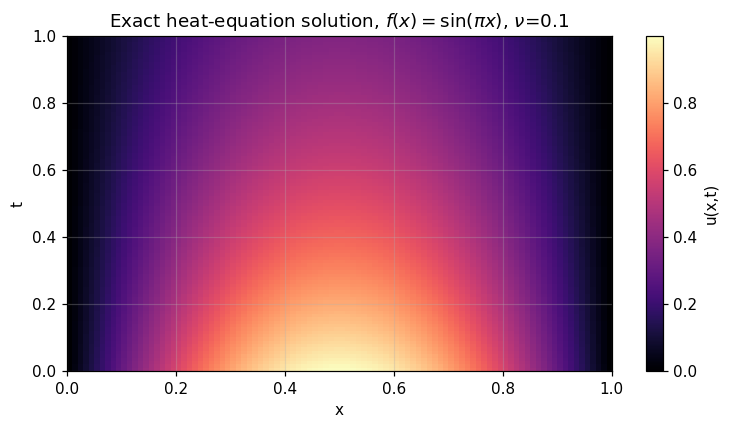

In [3]:
# ── Exact reference solution via sine-mode decay ────────────────────────────
NU   = 0.10       # diffusivity
TMAX = 1.0        # final time
L    = 1.0

def exact_from_modes(coeffs, x, t):
    "u(x,t) for f(x)=sum_k coeffs[k-1] sin(k pi x), Dirichlet BCs."
    x = np.asarray(x)[:, None] if np.ndim(x) else np.array([[x]])
    u = np.zeros((len(x),))
    for k, a in enumerate(coeffs, start=1):
        u += a * np.exp(-NU * (k*np.pi)**2 * t) * np.sin(k*np.pi*x[:,0])
    return u

# Reference IC for the forward PINN demo: a single sine (clean analytical target)
IC_COEFFS = [1.0]                          # f(x) = sin(pi x)
nx, nt = 100, 100
xg = np.linspace(0, L, nx)
tg = np.linspace(0, TMAX, nt)
U_ref = np.zeros((nt, nx))
for j, tt in enumerate(tg):
    U_ref[j] = exact_from_modes(IC_COEFFS, xg, tt)

fig, ax = plt.subplots(figsize=(7,4))
im = ax.imshow(U_ref, origin="lower", aspect="auto", extent=[0,L,0,TMAX], cmap="magma")
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(f"Exact heat-equation solution, $f(x)=\\sin(\\pi x)$, $\\nu$={NU}")
plt.colorbar(im, label="u(x,t)"); plt.tight_layout(); plt.show()


---
## §2 — A PINN for the heat equation (forward, hard constraints)

The network now takes **two inputs** $(x,t)$ and outputs $u$. The physics residual needs a **second spatial
derivative** $u_{xx}$, which we get with *two* autograd passes — the same mechanism as notebook 1, one level
deeper.

We again use a **hard-constraint ansatz** so the IC and both Dirichlet BCs are satisfied exactly, leaving the
optimizer to focus purely on the PDE:

$$u(x,t) = f(x) \;+\; t\,x\,(1-x)\,\mathcal{N}_\theta(x,t).$$

Check it: at $t=0$ it returns $f(x)$ (IC ✓); at $x=0$ or $x=1$ the correction vanishes and $f$ is zero there
(BCs ✓). Elegant and free.

In [4]:
# ── Hard-constraint PINN for the heat equation ──────────────────────────────
def f_ic(x):
    "Initial condition f(x) = sin(pi x), as a torch tensor op."
    return torch.sin(np.pi * x)

def make_pde_net(**kw):
    torch.manual_seed(SEED)
    d = dict(in_features=2, out_features=1, num_layers=5, layer_size=64,
             activation_fn="tanh", weight_norm=True)
    d.update(kw)
    return FullyConnected(**d).to(device)

def u_hard(net, x, t):
    "u(x,t) = f(x) + t*x*(1-x)*N(x,t)  -> exact IC + Dirichlet BCs."
    N = net(torch.cat([x, t], dim=1))
    return f_ic(x) + t * x * (1 - x) * N

def heat_residual(net, x, t, nu):
    "PDE residual r = u_t - nu u_xx via double autograd."
    u   = u_hard(net, x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    return u_t - nu * u_xx

def sample_collocation(n):
    x = torch.rand(n, 1, device=device, requires_grad=True)
    t = (torch.rand(n, 1, device=device) * TMAX).requires_grad_(True)
    return x, t

def train_heat_pinn(net, nu=NU, n_iter=None, n_col=1000, lr=3e-3, log_every=200):
    n_iter = NI(600) if n_iter is None else n_iter
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    hist = []
    for it in range(n_iter):
        opt.zero_grad()
        x, t = sample_collocation(n_col)          # fresh points each step (stochastic collocation)
        r = heat_residual(net, x, t, nu)
        loss = (r**2).mean()
        loss.backward(); opt.step(); hist.append(loss.item())
        if it % log_every == 0: print(f"  it {it:5d} | residual {loss.item():.2e}")
    return np.array(hist)

net_pde = make_pde_net()
print("Training heat-equation PINN on CPU...")
with Timer() as tmr:
    hist_pde = train_heat_pinn(net_pde)
print(f"done in {tmr.dt:.1f}s")


Training heat-equation PINN on CPU...
  it     0 | residual 6.80e-01


  it   200 | residual 1.44e-04


  it   400 | residual 3.54e-05


done in 17.0s


PINN relative L2 error over the whole domain: 0.013


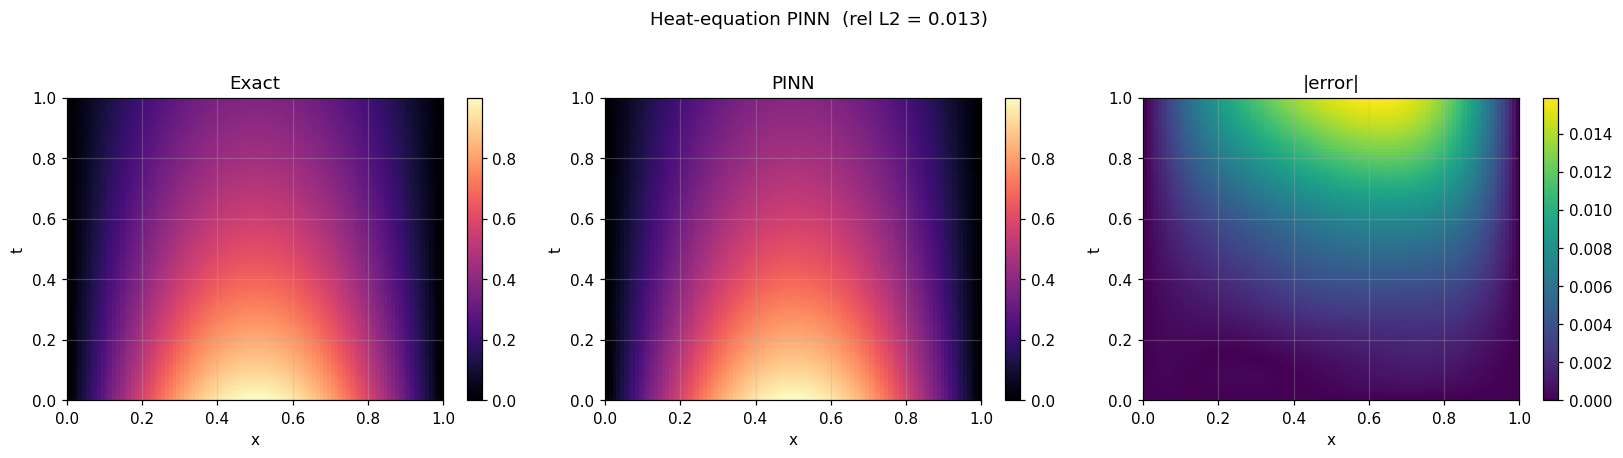

In [5]:
# ── Evaluate the PINN on the full (x,t) grid and compare to exact ───────────
def pinn_field(net):
    X, T = np.meshgrid(xg, tg)
    xf = torch.tensor(X.reshape(-1,1), dtype=torch.float32)
    tf = torch.tensor(T.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        u = u_hard(net, xf, tf).numpy().reshape(T.shape)
    return u

U_pinn = pinn_field(net_pde)
err = rel_l2(U_pinn, U_ref)
print("PINN relative L2 error over the whole domain:", round(err, 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, U, title in [(axes[0], U_ref, "Exact"), (axes[1], U_pinn, "PINN"),
                     (axes[2], np.abs(U_pinn-U_ref), "|error|")]:
    im = ax.imshow(U, origin="lower", aspect="auto", extent=[0,L,0,TMAX],
                   cmap="magma" if title!="|error|" else "viridis")
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("t"); plt.colorbar(im, ax=ax)
plt.suptitle(f"Heat-equation PINN  (rel L2 = {err:.3f})", y=1.03)
plt.tight_layout(); plt.show()


### Temperature profiles at several times

A PINN gives a **continuous** solution — we can query it at any $(x,t)$ without a mesh. Let's slice the field at
a few times and overlay the exact curves.

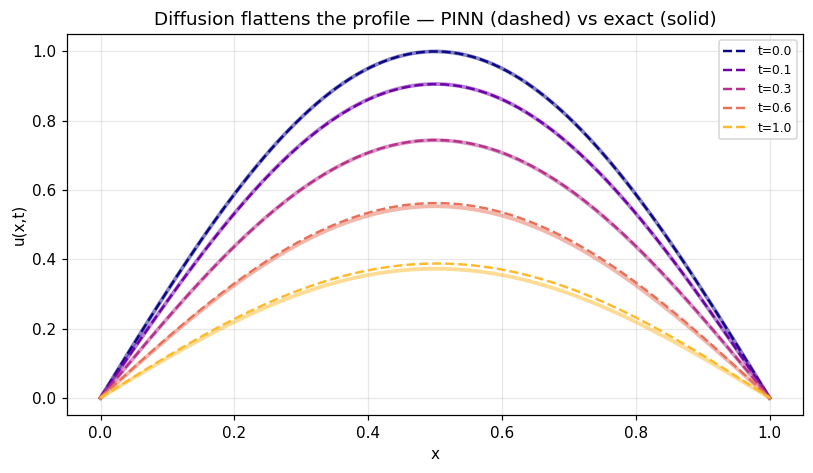

In [6]:
# ── Snapshots u(x, t=const) ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5,4.4))
snap_t = [0.0, 0.1, 0.3, 0.6, 1.0]
colors = plt.cm.plasma(np.linspace(0,0.85,len(snap_t)))
for tt, c in zip(snap_t, colors):
    u_ex = exact_from_modes(IC_COEFFS, xg, tt)
    j = int(round(tt/TMAX*(nt-1)))
    ax.plot(xg, u_ex, color=c, lw=2.5, alpha=0.5)
    ax.plot(xg, U_pinn[j], "--", color=c, lw=1.6, label=f"t={tt}")
ax.set_xlabel("x"); ax.set_ylabel("u(x,t)")
ax.set_title("Diffusion flattens the profile — PINN (dashed) vs exact (solid)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


---
## §4 — Comparing PINN settings on a PDE

Spectral bias bites harder in 2-D. We compare a few Modulus `FullyConnected` configurations, all with hard
constraints and the same budget, and rank them by relative-L2 error over the domain.

  it     0 | residual 4.36e-01


tanh                 | rel L2 = 0.0040 |  8.4s
  it     0 | residual 6.86e-01


tanh + weight_norm   | rel L2 = 0.0018 |  8.1s


  it     0 | residual 5.30e-01


silu                 | rel L2 = 0.0006 | 15.5s
  it     0 | residual 5.26e-01


gelu                 | rel L2 = 0.0004 | 12.7s


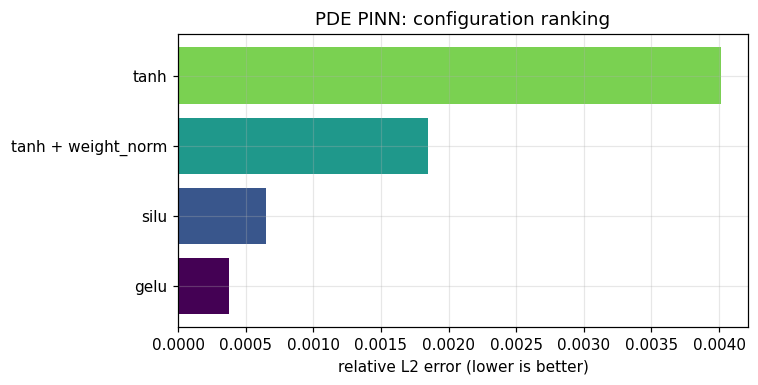

In [7]:
# ── PDE settings sweep ──────────────────────────────────────────────────────
pde_configs = {
    "tanh":               dict(activation_fn="tanh",  weight_norm=False),
    "tanh + weight_norm": dict(activation_fn="tanh",  weight_norm=True),
    "silu":               dict(activation_fn="silu",  weight_norm=True),
    "gelu":               dict(activation_fn="gelu",  weight_norm=True),
}
pde_sweep = {}
for name, cfg in pde_configs.items():
    net = make_pde_net(**cfg)
    with Timer() as tmr:
        _ = train_heat_pinn(net, n_iter=NI(400), n_col=800, log_every=10_000)
    U = pinn_field(net); e = rel_l2(U, U_ref)
    pde_sweep[name] = dict(err=e, time=tmr.dt)
    print(f"{name:20s} | rel L2 = {e:.4f} | {tmr.dt:4.1f}s")

fig, ax = plt.subplots(figsize=(7,3.6))
names = list(pde_sweep); errs = [pde_sweep[n]["err"] for n in names]
order = np.argsort(errs)
ax.barh([names[i] for i in order], [errs[i] for i in order], color=plt.cm.viridis(np.linspace(0,.8,len(names))))
ax.set_xlabel("relative L2 error (lower is better)"); ax.set_title("PDE PINN: configuration ranking")
plt.tight_layout(); plt.show()


---
## §5 — Inverse PDE: recovering the diffusivity $\nu$ from data

Now the inverse problem: we **don't know** $\nu$. We have sparse, noisy sensor readings of $u$ scattered in
space and time, and we want to recover the material property $\nu$ *and* the full field. As in notebook 1, $\nu$
becomes a trainable parameter, we up-weight the data term to avoid co-adaptation, and give $\nu$ its own faster
learning rate.

In [8]:
# ── Generate sparse noisy sensor data from the true field ───────────────────
rng = np.random.default_rng(SEED)
N_SENSORS, NOISE = 60, 0.02
xs = rng.uniform(0, L, N_SENSORS)
ts = rng.uniform(0, TMAX, N_SENSORS)
us = np.array([exact_from_modes(IC_COEFFS, [xi], ti)[0] for xi, ti in zip(xs, ts)])
us_noisy = us + NOISE * rng.standard_normal(us.shape)

xs_t = torch.tensor(xs, dtype=torch.float32).view(-1,1).requires_grad_(True)
ts_t = torch.tensor(ts, dtype=torch.float32).view(-1,1).requires_grad_(True)
us_t = torch.tensor(us_noisy, dtype=torch.float32).view(-1,1)

# trainable diffusivity (softplus keeps it positive), started at a wrong guess
raw_nu = torch.nn.Parameter(torch.tensor(-1.0))     # softplus(-1)=0.31 -> far from 0.10
def nu_val(): return torch.nn.functional.softplus(raw_nu)

inv_net = make_pde_net()
opt = torch.optim.Adam([{"params": inv_net.parameters(), "lr": 3e-3},
                        {"params": [raw_nu],            "lr": 2e-2}])
W_DATA = 30.0
nu_track, loss_track = [], []
print("Recovering nu from noisy sensor data...  (true nu = 0.10)")
for it in range(NI(1200)):
    opt.zero_grad()
    nu = nu_val()
    u_pred = u_hard(inv_net, xs_t, ts_t)
    loss_data = ((u_pred - us_t)**2).mean()
    xc, tc = sample_collocation(1000)
    r = heat_residual(inv_net, xc, tc, nu)
    loss = W_DATA*loss_data + (r**2).mean()
    loss.backward(); opt.step()
    nu_track.append(nu.item()); loss_track.append(loss.item())
    if it % 1000 == 0: print(f"  it {it:5d} | loss {loss.item():.2e} | nu = {nu.item():.4f}")
print(f"\nRecovered nu = {nu_val().item():.4f}   (true 0.10)")


Recovering nu from noisy sensor data...  (true nu = 0.10)
  it     0 | loss 9.94e+00 | nu = 0.3133


  it  1000 | loss 1.10e-02 | nu = 0.0996



Recovered nu = 0.0996   (true 0.10)


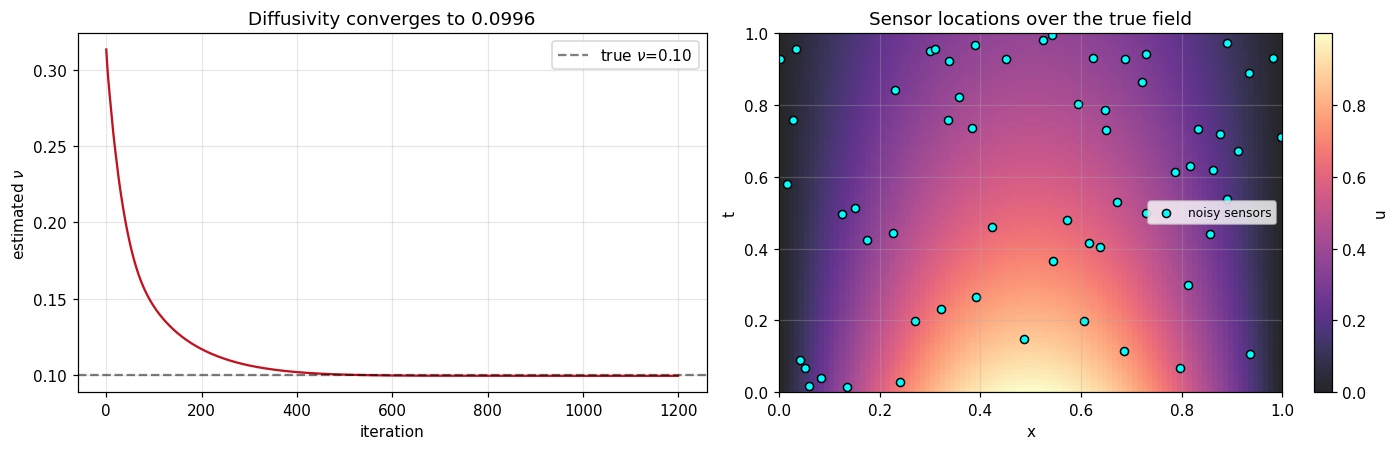

In [9]:
# ── Show nu convergence and the sensor layout ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,4.2))
ax1.plot(nu_track, color="#c1121f"); ax1.axhline(NU, ls="--", color="k", alpha=0.5, label="true $\\nu$=0.10")
ax1.set_xlabel("iteration"); ax1.set_ylabel("estimated $\\nu$")
ax1.set_title(f"Diffusivity converges to {nu_val().item():.4f}"); ax1.legend()

im = ax2.imshow(U_ref, origin="lower", aspect="auto", extent=[0,L,0,TMAX], cmap="magma", alpha=0.85)
ax2.scatter(xs, ts, c="cyan", edgecolor="k", s=28, label="noisy sensors")
ax2.set_xlabel("x"); ax2.set_ylabel("t"); ax2.set_title("Sensor locations over the true field")
ax2.legend(fontsize=8); plt.colorbar(im, ax=ax2, label="u")
plt.tight_layout(); plt.show()


---
## §6 — The wall: change the initial condition, and the PINN must retrain

Here is the fundamental limitation. Our PINN learned the solution for **one specific** IC, $f(x)=\sin(\pi x)$.
Suppose a new batch arrives with a **different** initial temperature profile, say
$f(x)=\sin(\pi x)+0.5\sin(3\pi x)$. The trained network knows nothing about it — we have to **train a whole new
PINN**. Let's time that.

In [10]:
# ── A new IC => a brand-new PINN training run ───────────────────────────────
NEW_COEFFS = [1.0, 0.0, 0.5]     # f(x) = sin(pi x) + 0.5 sin(3 pi x)

def f_ic_new(x):
    return torch.sin(np.pi*x) + 0.5*torch.sin(3*np.pi*x)

def u_hard_new(net, x, t):
    N = net(torch.cat([x, t], dim=1))
    return f_ic_new(x) + t*x*(1-x)*N

def heat_res_new(net, x, t, nu):
    u = u_hard_new(net, x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    return u_t - nu*u_xx

net_new = make_pde_net()
opt = torch.optim.Adam(net_new.parameters(), lr=3e-3)
print("Retraining a NEW PINN for the NEW initial condition...")
with Timer() as tmr_pinn_retrain:
    for it in range(NI(600)):
        opt.zero_grad()
        x, t = sample_collocation(1000)
        (heat_res_new(net_new, x, t, NU)**2).mean().backward(); opt.step()
print(f"retraining took {tmr_pinn_retrain.dt:.1f}s  (for ONE new IC)")

# reference for the new IC
U_ref_new = np.zeros((nt, nx))
for j, tt in enumerate(tg): U_ref_new[j] = exact_from_modes(NEW_COEFFS, xg, tt)
X, T = np.meshgrid(xg, tg)
xf = torch.tensor(X.reshape(-1,1), dtype=torch.float32, requires_grad=True)
tf = torch.tensor(T.reshape(-1,1), dtype=torch.float32, requires_grad=True)
U_pinn_new = u_hard_new(net_new, xf, tf).detach().numpy().reshape(T.shape)
print("new-IC PINN rel L2:", round(rel_l2(U_pinn_new, U_ref_new), 4))
print("\n>>> Every new initial condition costs another full training run. This is the motivation for operators.")


Retraining a NEW PINN for the NEW initial condition...


retraining took 22.7s  (for ONE new IC)
new-IC PINN rel L2: 0.0229

>>> Every new initial condition costs another full training run. This is the motivation for operators.


---
## §7 — The Fourier Neural Operator: learn the *map*, not the function

Instead of learning $u(x,t)$ for one IC, an **FNO learns an operator**

$$\mathcal{G}_\theta:\; f(\cdot)\ \longmapsto\ u(\cdot,\,T),$$

i.e. it maps the **whole initial profile** $f(x)$ (sampled on a grid) to the **whole solution** at final time $T$.
Train it once on many random ICs, and it predicts the solution for any *new* IC in a single forward pass.

**How the FNO works (intuition).** A standard conv net mixes information locally. The FNO instead does its mixing
in **Fourier space**: each layer (i) FFTs the signal, (ii) keeps the lowest $k$ Fourier modes and applies a
learned complex weight to each, (iii) inverse-FFTs, and adds a local linear term. Because differentiation and
diffusion are *diagonal in Fourier space*, this is a remarkably natural basis for PDE solution operators — and it
makes the FNO **resolution-invariant** (more on that in §10).

NVIDIA Modulus ships a production FNO as `modulus.models.fno.FNO`. We'll use the 1-D version on CPU.

dataset shapes: (500, 1, 64) -> (500, 1, 64)


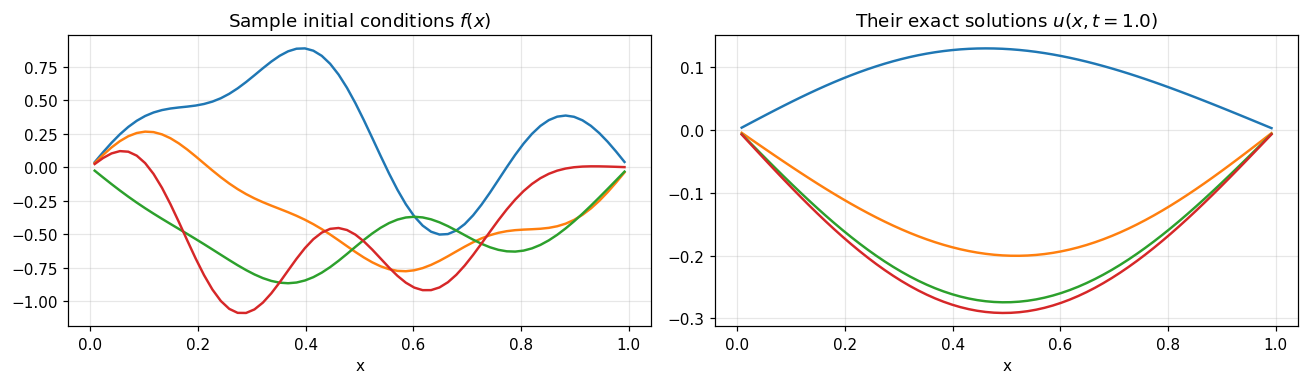

In [11]:
# ── Build a dataset of (initial condition  ->  solution at T) pairs ─────────
GRID = 64                                  # spatial resolution for the operator
x_op = np.linspace(0, L, GRID, endpoint=False) + 0.5*L/GRID   # cell centers in (0,1)
KMAX = 6                                    # ICs are random combinations of the first 6 sine modes

def random_ic_batch(n, kmax=KMAX, seed=None):
    "Return (f_grid, uT_grid): n random ICs and their exact solutions at t=TMAX."
    r = np.random.default_rng(seed)
    F  = np.zeros((n, GRID)); UT = np.zeros((n, GRID))
    for i in range(n):
        a = r.standard_normal(kmax) / (np.arange(1, kmax+1))     # decaying amplitudes -> smooth ICs
        for k in range(1, kmax+1):
            F[i]  += a[k-1] * np.sin(k*np.pi*x_op)
            UT[i] += a[k-1] * np.exp(-NU*(k*np.pi)**2*TMAX) * np.sin(k*np.pi*x_op)
    return F, UT

N_TRAIN, N_TEST = 500, 200
F_tr, U_tr = random_ic_batch(N_TRAIN, seed=1)
F_te, U_te = random_ic_batch(N_TEST,  seed=2)

# FNO expects (batch, channels, length)
Xtr = torch.tensor(F_tr, dtype=torch.float32).unsqueeze(1)
Ytr = torch.tensor(U_tr, dtype=torch.float32).unsqueeze(1)
Xte = torch.tensor(F_te, dtype=torch.float32).unsqueeze(1)
Yte = torch.tensor(U_te, dtype=torch.float32).unsqueeze(1)
print("dataset shapes:", tuple(Xtr.shape), "->", tuple(Ytr.shape))

fig, ax = plt.subplots(1, 2, figsize=(12,3.6))
for i in range(4):
    ax[0].plot(x_op, F_tr[i], lw=1.6); ax[1].plot(x_op, U_tr[i], lw=1.6)
ax[0].set_title("Sample initial conditions $f(x)$"); ax[0].set_xlabel("x")
ax[1].set_title(f"Their exact solutions $u(x, t={TMAX})$"); ax[1].set_xlabel("x")
plt.tight_layout(); plt.show()


In [12]:
# ── Train the NVIDIA Modulus FNO operator ───────────────────────────────────
torch.manual_seed(SEED)
fno = FNO(
    in_channels=1, out_channels=1, dimension=1,
    latent_channels=32,        # width of the FNO's hidden representation
    num_fno_layers=4,          # number of spectral-conv layers
    num_fno_modes=16,          # Fourier modes kept per layer (the key capacity knob)
    padding=8,                 # padding to reduce FFT periodicity artifacts
    decoder_layers=2, decoder_layer_size=64,
).to(device)
n_params = sum(p.numel() for p in fno.parameters())
print(f"FNO parameters: {n_params:,}")

opt = torch.optim.Adam(fno.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=NI(70), gamma=0.5)
lossf = nn.MSELoss()
train_hist, test_hist = [], []

print("Training the operator on CPU...")
with Timer() as tmr:
    for ep in range(NI(180)):
        opt.zero_grad()
        loss = lossf(fno(Xtr), Ytr)
        loss.backward(); opt.step(); sched.step()
        train_hist.append(loss.item())
        if ep % 20 == 0:
            with torch.no_grad(): te = lossf(fno(Xte), Yte).item()
            test_hist.append((ep, te))
            print(f"  epoch {ep:4d} | train {loss.item():.2e} | test {te:.2e}")
print(f"trained in {tmr.dt:.1f}s")

with torch.no_grad():
    rel = (torch.norm(fno(Xte)-Yte)/torch.norm(Yte)).item()
print(f"FNO relative L2 on {N_TEST} UNSEEN initial conditions: {rel:.4f}")


FNO parameters: 142,225
Training the operator on CPU...


  epoch    0 | train 7.19e-02 | test 7.01e-02


  epoch   20 | train 9.04e-03 | test 7.19e-03


  epoch   40 | train 6.74e-03 | test 6.54e-03


  epoch   60 | train 4.40e-03 | test 4.22e-03


...

  epoch  100 | train 2.14e-03 | test 2.08e-03


  epoch  120 | train 1.23e-03 | test 1.21e-03


  epoch  140 | train 7.27e-04 | test 7.50e-04


  epoch  160 | train 5.85e-04 | test 6.12e-04


trained in 50.3s
FNO relative L2 on 200 UNSEEN initial conditions: 0.0851


---
## §8 — The payoff: new initial conditions, **zero retraining**

This is the whole point. The FNO was trained on random ICs. Now we hand it **completely new** initial
conditions — including ones structurally unlike the training set — and it produces the solution in a **single
forward pass** (milliseconds), with **no retraining**. Contrast that with §6, where each new IC cost a full
PINN training run.

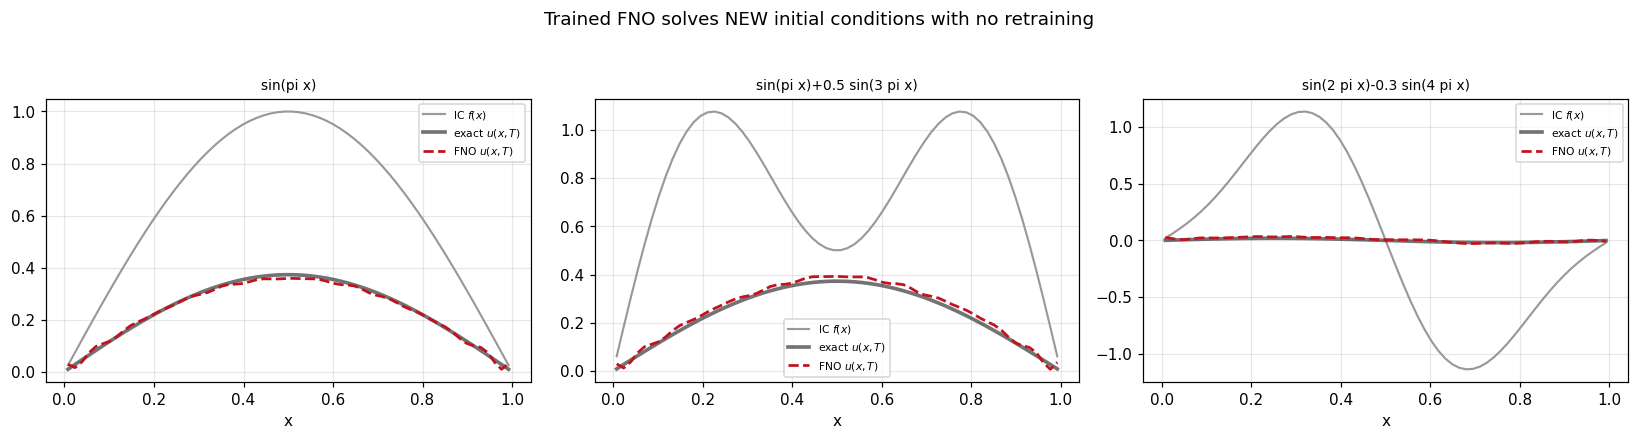

~7.9 ms per solve (inference), vs ~23 s to retrain a PINN per IC


In [13]:
# ── Evaluate the trained operator on brand-new ICs, instantly ───────────────
def solve_with_fno(f_grid):
    with torch.no_grad():
        xin = torch.tensor(f_grid, dtype=torch.float32).view(1,1,-1)
        return fno(xin).squeeze().numpy()

# three hand-picked ICs the FNO never saw
new_ics = {
    "sin(pi x)":                 np.sin(np.pi*x_op),
    "sin(pi x)+0.5 sin(3 pi x)": np.sin(np.pi*x_op)+0.5*np.sin(3*np.pi*x_op),
    "sin(2 pi x)-0.3 sin(4 pi x)": np.sin(2*np.pi*x_op)-0.3*np.sin(4*np.pi*x_op),
}
fig, axes = plt.subplots(1, 3, figsize=(15,3.8))
t0 = time.time()
for ax, (name, f) in zip(axes, new_ics.items()):
    # exact solution at T for this IC
    u_exact = np.zeros(GRID)
    # decompose onto sine modes numerically for the reference
    for k in range(1, KMAX+3):
        ak = 2*np.trapezoid(f*np.sin(k*np.pi*x_op), x_op)          # sine coefficient
        u_exact += ak*np.exp(-NU*(k*np.pi)**2*TMAX)*np.sin(k*np.pi*x_op)
    u_fno = solve_with_fno(f)
    ax.plot(x_op, f, color="#999", lw=1.4, label="IC $f(x)$")
    ax.plot(x_op, u_exact, "k-", lw=2.4, alpha=0.55, label="exact $u(x,T)$")
    ax.plot(x_op, u_fno, "--", color="#c1121f", lw=1.8, label="FNO $u(x,T)$")
    ax.set_title(name, fontsize=9); ax.set_xlabel("x"); ax.legend(fontsize=7)
infer_ms = (time.time()-t0)*1000/len(new_ics)
plt.suptitle("Trained FNO solves NEW initial conditions with no retraining", y=1.04)
plt.tight_layout(); plt.show()
print(f"~{infer_ms:.1f} ms per solve (inference), vs ~{tmr_pinn_retrain.dt:.0f} s to retrain a PINN per IC")


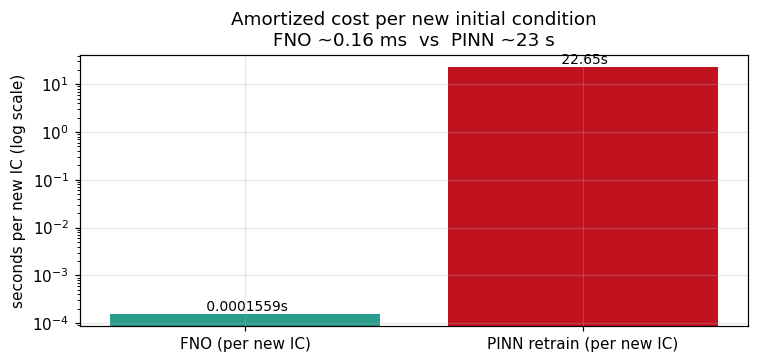

Speedup per new IC: ~145,315x  (this is the digital-twin advantage)


In [14]:
# ── Speed comparison: operator inference vs per-IC PINN retraining ──────────
with torch.no_grad():
    t0 = time.time(); _ = fno(Xte); fno_batch = time.time()-t0
per_ic_fno = fno_batch/N_TEST
per_ic_pinn = tmr_pinn_retrain.dt          # one retrain measured in §6

fig, ax = plt.subplots(figsize=(7,3.4))
ax.bar(["FNO (per new IC)", "PINN retrain (per new IC)"],
       [per_ic_fno, per_ic_pinn], color=["#2a9d8f", "#c1121f"], log=True)
ax.set_ylabel("seconds per new IC (log scale)")
ax.set_title(f"Amortized cost per new initial condition\nFNO ~{per_ic_fno*1e3:.2f} ms  vs  PINN ~{per_ic_pinn:.0f} s")
for i,v in enumerate([per_ic_fno, per_ic_pinn]):
    ax.text(i, v, f" {v:.4g}s", va="bottom", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"Speedup per new IC: ~{per_ic_pinn/per_ic_fno:,.0f}x  (this is the digital-twin advantage)")


---
## §9 — Resolution invariance: train coarse, evaluate fine

Because the FNO parameterizes its operator in **Fourier modes** (not grid pixels), the same trained weights act
on a grid of *any* resolution. We trained on `GRID = 64`. Let's feed the same operator an IC sampled on a
**finer** grid and check it still produces the right answer — a *zero-shot super-resolution* property that mesh
solvers and standard CNNs don't have.

*(Caveat: this holds while the solution's active Fourier content stays within the modes the FNO learned; very
high-frequency features beyond `num_fno_modes` won't be captured.)*

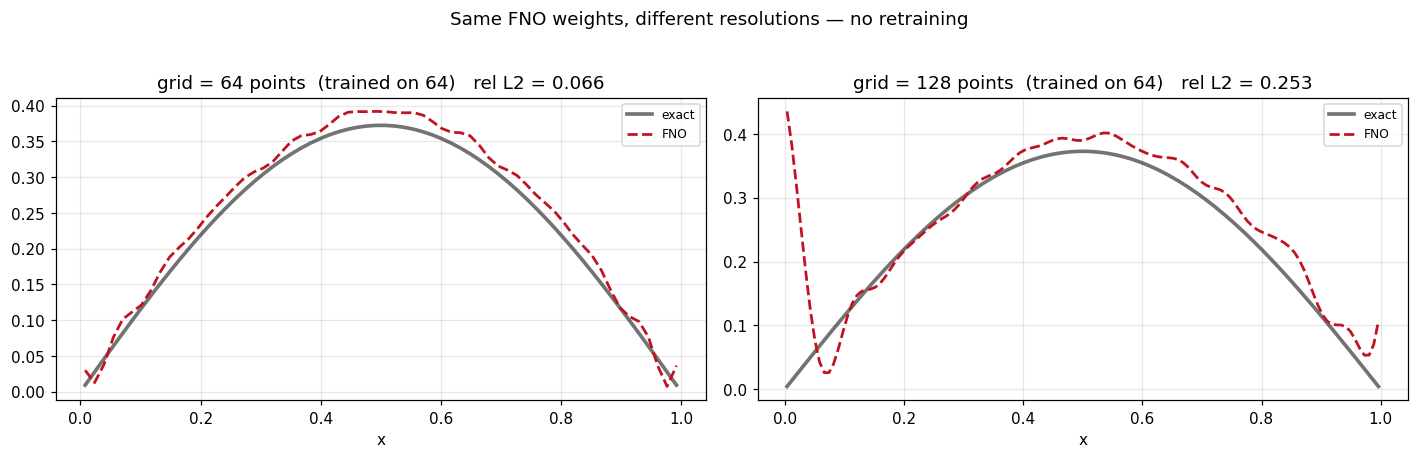

In [15]:
# ── Zero-shot evaluation on a finer grid ────────────────────────────────────
def eval_at_resolution(G):
    xr = np.linspace(0, L, G, endpoint=False) + 0.5*L/G
    f  = np.sin(np.pi*xr) + 0.5*np.sin(3*np.pi*xr)         # same IC, finer sampling
    u_exact = (np.exp(-NU*(np.pi)**2*TMAX)*np.sin(np.pi*xr)
               + 0.5*np.exp(-NU*(3*np.pi)**2*TMAX)*np.sin(3*np.pi*xr))
    with torch.no_grad():
        u_fno = fno(torch.tensor(f, dtype=torch.float32).view(1,1,-1)).squeeze().numpy()
    return xr, f, u_exact, u_fno, rel_l2(u_fno, u_exact)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for ax, G in zip(axes, [64, 128]):
    xr, f, ue, uf, e = eval_at_resolution(G)
    ax.plot(xr, ue, "k-", lw=2.4, alpha=0.55, label="exact")
    ax.plot(xr, uf, "--", color="#c1121f", lw=1.8, label="FNO")
    ax.set_title(f"grid = {G} points  (trained on 64)   rel L2 = {e:.3f}")
    ax.set_xlabel("x"); ax.legend(fontsize=8)
plt.suptitle("Same FNO weights, different resolutions — no retraining", y=1.03)
plt.tight_layout(); plt.show()


---
## §10 — Beyond vanilla FNO (what Modulus gives you next)

The `nvidia-modulus` model zoo has a whole family of operators and architectures you can drop in the same way.
A few worth knowing, all in `modulus.models`:

- **AFNO** (`afno`) — Adaptive FNO with a token-mixing MLP in Fourier space; the backbone NVIDIA uses for
  large weather/climate emulators (FourCastNet).
- **Transolver** (`transolver`) — a transformer-based PDE solver for complex geometries.
- **Pix2Pix / U-Net** (`pix2pix`, `unet`) — image-to-image operators for 2-D fields.
- **DeepONet** (branch/trunk operator) — the other major neural-operator family; excellent when inputs are
  functions sampled at arbitrary (non-grid) locations.

And the idea that combines both worlds: a **Physics-Informed Neural Operator (PINO)** adds a PDE-residual loss
(like our PINN) *on top of* the FNO's data loss, so the operator respects the physics and needs less data. Below
we just confirm the Modulus **AFNO** block instantiates and runs on CPU — wiring it into the training loop above
is a one-line swap.

In [16]:
# ── Confirm an advanced Modulus operator instantiates on CPU ────────────────
from modulus.models.afno import AFNO
try:
    afno = AFNO(
        inp_shape=[GRID, 1], in_channels=1, out_channels=1,
        patch_size=[8, 1], embed_dim=32, depth=2, num_blocks=4,
    )
    with torch.no_grad():
        y = afno(torch.randn(2, 1, GRID, 1))
    print("AFNO OK -> output shape", tuple(y.shape))
except Exception as e:
    # AFNO is 2D-oriented; if the 1D-style call signature differs in this version,
    # the takeaway stands: it's the same modulus.models API, swapped in.
    print("AFNO instantiation note:", repr(e)[:160])
    print("(AFNO targets 2D fields; for our 1D operator, FNO above is the right tool.)")


AFNO OK -> output shape (2, 1, 64, 1)


---
## §11 — Summary: PINN vs Neural Operator

| | **PINN** (§2–§6) | **FNO / Neural Operator** (§7–§10) |
|---|---|---|
| Learns | one solution $u(x,t)$ | the operator $f\mapsto u(\cdot,T)$ |
| Data needed | none (physics only) | a dataset of solved instances (or physics via PINO) |
| New IC/BC | **retrain from scratch** | **single forward pass, no retraining** |
| Cost per new case | seconds–minutes | milliseconds |
| Inverse problems | natural (trainable params) | possible, less direct |
| Resolution | continuous, mesh-free | resolution-invariant (within learned modes) |
| Best for | one-off solves, inversion, data assimilation | many queries, real-time surrogates, **digital twins** |

**The mental model.** A PINN *is* a solver you train per problem; a neural operator *is* a solver you train once
for a whole problem family. NVIDIA leans on the operator idea precisely because a digital twin must answer
thousands of "what-if" queries per second — impossible if each one is a fresh PINN solve, trivial once you've
learned the operator.

They're complementary: use PINNs for inversion and one-off high-fidelity solves; use operators (optionally
physics-informed, PINO-style) for fast, repeated evaluation.

### The production path
On GPU, NVIDIA **PhysicsNeMo** (the renamed Modulus) scales exactly these building blocks — `FNO`, `AFNO`,
`DeepONet`, `Transolver` — to 2-D/3-D fields, multi-GPU training, and real industrial geometries, which is what
powers the digital-twin and simulation-acceleration work your colleague mentioned. Everything you built here is
the same API, one resolution and one device larger.

---
## References

1. **Li et al. (2021).** *Fourier Neural Operator for Parametric PDEs.* ICLR. — the FNO.
2. **Lu, Jin, Pang, Zhang & Karniadakis (2021).** *DeepONet.* Nature Machine Intelligence 3, 218–229. — operator learning.
3. **Raissi, Perdikaris & Karniadakis (2019).** *Physics-informed neural networks.* J. Comput. Phys. 378, 686–707.
4. **Karniadakis et al. (2021).** *Physics-informed machine learning.* Nature Reviews Physics 3, 422–440.
5. **Wang, Wang & Perdikaris (2021 / PINO line of work).** *Physics-informed neural operators.* — combining operators with physics losses.
6. **Cai, Wang, Wang, Perdikaris & Karniadakis (2021).** *PINNs for heat transfer.* — heat-equation PINNs and inverse problems.
7. **NVIDIA Modulus / PhysicsNeMo documentation** — `FNO`, `AFNO`, and the model zoo used here.

*This completes the two-notebook set: **notebook 1** covered systems of ODEs (reaction kinetics: forward,
inverse, parameter estimation); **notebook 2** covered PDEs and the leap from single-instance PINNs to neural
operators for digital twins.*